
# Machine Translation: English → Marathi 🇮🇳

## 📌 Project Overview

This project demonstrates a **Machine Translation (MT)** task using a **pre-trained Transformer model** for translating text from **English to Marathi**.

Due to the high computational cost and time required to train machine translation models from scratch, this project focuses on:

* Using an **already pre-trained multilingual model**
* Performing **light fine-tuning**
* Understanding the **overall workflow** of a translation system
* Evaluating translation quality using the **BLEU score**

The main goal is **learning and experimentation**, not achieving state-of-the-art performance.

---

## 🎯 Objectives

* Understand how machine translation works using Transformer models
* Use a **pretrained multilingual model (mBART-50)**
* Perform **light fine-tuning** on an English–Marathi dataset
* Evaluate translations using **BLEU score**
* Visualize training behavior using **Matplotlib**

---

## 🔄 Translation Task

* **Source Language:** English
* **Target Language:** Marathi
* **Model Used:** `"aryaumesh/english-to-marathi"'

---

## 🧠 Model & Approach

* **Model:** mBART-50 (Multilingual Denoising Seq-to-Seq Transformer)
* **Tokenizer:** `MBart50TokenizerFast`
* **Training Strategy:**

  * No training from scratch
  * Only **light fine-tuning** on a small dataset
  * Default architecture and weights preserved

This approach helps reduce training time while still understanding the fine-tuning pipeline.

---

## 📊 Evaluation Metric – BLEU Score

The **BLEU (Bilingual Evaluation Understudy)** score is used to evaluate translation quality by comparing model-generated translations with reference translations.

* Higher BLEU score → Better translation quality
* Used mainly for **relative comparison**, not absolute correctness

---

## 📈 Visualization

Training progress and results are visualized using **Matplotlib**, such as:

* Training loss
* Evaluation loss (if enabled)

```python
import matplotlib.pyplot as plt
```

---

## 🛠️ Technologies & Libraries Used

```python
from datasets import load_dataset, DatasetDict
from transformers import (
    MBartForConditionalGeneration,
    MBart50TokenizerFast,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq
)
```

### Key Libraries:

* **Hugging Face Transformers**
* **Hugging Face Datasets**
* **PyTorch (backend)**
* **Matplotlib**
* **BLEU score (evaluation)**



## 📌 Key Learnings

* How multilingual Transformer models work
* How to fine-tune seq-to-seq models
* How BLEU score is calculated and interpreted
* How English → Marathi translation can be implemented practically

---

## 🔮 Future Improvements

* Use a larger and cleaner parallel dataset
* Perform longer fine-tuning with better hyperparameters
* Evaluate with additional metrics (METEOR, ROUGE)
* Add inference examples and UI

---

## 📚 Conclusion

This project provides a **hands-on overview** of a real-world **machine translation pipeline** using modern NLP tools.
It is designed as a **learning-oriented implementation** rather than a production-grade system.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Marathi_english.csv')
display(df.head())

,en,m
0,"In 1666, the Mughal emperor Aurangzeb summoned...","१६६६ मध्ये, मुघल सम्राट औरंगजेबने शिवाजी आणि त..."
1,The meeting quickly soured when Shivaji was di...,शाही दरबारात शिवाजीला कमी दर्जाच्या सरदारांसोब...
2,"Incensed, he stormed out and was immediately p...","संतप्त होऊन, ते बाहेर पडले आणि त्यांना तात्काळ..."
3,The guarantee for his custody was provided by ...,त्यांच्या नजरकैदेची हमी शक्तिशाली राजपूत सेनाप...
4,Shivaji's situation was extremely dangerous.,शिवाजींची परिस्थिती अत्यंत धोकादायक होती.


In [ ]:


import matplotlib.pyplot as plt
from datasets import load_dataset, DatasetDict
from transformers import (
    MBartForConditionalGeneration,
    MBart50TokenizerFast,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq
)

In [ ]:
model_checkpoint = "aryaumesh/english-to-marathi"

In [ ]:
from datasets import Dataset

In [ ]:
dataset = Dataset.from_pandas(df)
dataset = dataset.remove_columns(['__index_level_0__']) if '__index_level_0__' in dataset.column_names else dataset

In [ ]:
dataset

Dataset({
    features: ['en', 'm'],
    num_rows: 97
})

In [ ]:
dataset_split = dataset.train_test_split(test_size=0.2, seed=42)

datasets = DatasetDict({
    "train": dataset_split["train"],
    "eval": dataset_split["test"]
})

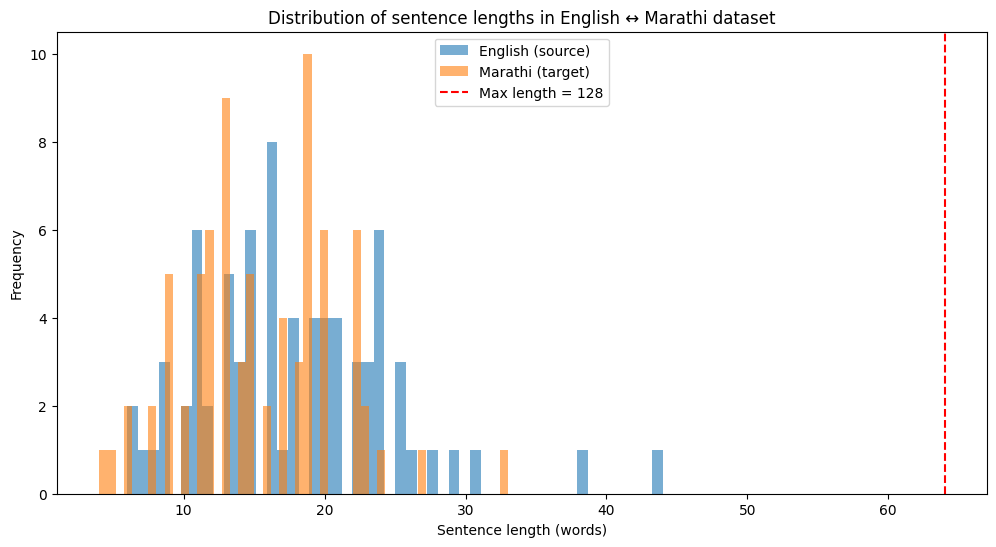

In [ ]:
import matplotlib.pyplot as plt


train_data = datasets['train']

en_lengths = [len(ex["en"].split()) for ex in train_data]
mr_lengths = [len(ex["m"].split()) for ex in train_data]


plt.figure(figsize=(12,6))

plt.hist(en_lengths, bins=50, alpha=0.6, label="English (source)")
plt.hist(mr_lengths, bins=50, alpha=0.6, label="Marathi (target)")

plt.axvline(64, color='red', linestyle='--', label="Max length = 128")
plt.xlabel("Sentence length (words)")
plt.ylabel("Frequency")
plt.title("Distribution of sentence lengths in English ↔ Marathi dataset")
plt.legend()
plt.show()

In [ ]:
max_source_length = 64
max_target_length = 64

In [ ]:
tokenizer = MBart50TokenizerFast.from_pretrained(model_checkpoint)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


In [ ]:
def preprocess_function(examples):
    inputs = examples["en"]
    targets = examples["m"]

    model_inputs = tokenizer(
        inputs, max_length=max_source_length, truncation=True
    )

    with tokenizer.as_target_tokenizer():
        labels = tokenizer(
            targets, max_length=max_target_length, truncation=True
        )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_datasets = datasets.map(
    preprocess_function,
    batched=True,
    remove_columns=datasets["train"].column_names,
)

Map:   0%|          | 0/77 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4006: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/20 [00:00<?, ? examples/s]

In [ ]:
%pip install evaluate

In [ ]:
import evaluate

In [ ]:
pip install sacrebleu

In [ ]:
metric = evaluate.load("sacrebleu")

def postprocess_text(preds, labels):
    preds = [pred.strip() for pred in preds]
    labels = [[label.strip()] for label in labels]
    return preds, labels

import numpy as np

def compute_metrics(eval_pred):
    preds, labels = eval_pred
    if isinstance(preds, tuple):
        preds = preds[0]

    preds = np.argmax(preds, axis=-1) if preds.ndim == 3 else preds


    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds, decoded_labels = postprocess_text(decoded_preds, decoded_labels)
    result = metric.compute(predictions=decoded_preds, references=decoded_labels)
    return {"bleu": result["score"]}


In [ ]:
from transformers import MBartForConditionalGeneration, MBart50TokenizerFast, Seq2SeqTrainer, Seq2SeqTrainingArguments
from peft import LoraConfig, get_peft_model


In [ ]:
model = MBartForConditionalGeneration.from_pretrained(model_checkpoint)

In [ ]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.001,
    bias="none",
    task_type="SEQ_2_SEQ_LM"
)


In [ ]:
model = get_peft_model(model, lora_config)


In [ ]:
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, padding=True)


In [ ]:
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments, EarlyStoppingCallback

training_args = Seq2SeqTrainingArguments(
    output_dir="./finetuned-en-mr",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=1e-4,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,

    weight_decay=0.0001,
    save_total_limit=2,

    num_train_epochs=18,
    predict_with_generate=True,

    fp16=True,
    load_best_model_at_end=True,

    logging_dir="./logs",
    logging_strategy="steps",
    logging_steps=5,

    eval_accumulation_steps=1,
    report_to="none",
    push_to_hub=False
)



In [ ]:
# print("Vocab size:", tokenizer.vocab_size)

# def check_dataset(ds, tokenizer):
#     for i in range(80):
#         sample = ds[i]
#         for k in ['input_ids', 'labels']:
#             if k in sample:
#                 arr = sample[k]
#                 bad = [x for x in arr if (x < 0 or x >= tokenizer.vocab_size)]
#                 if bad:
#                     print(f"❌ Found bad IDs in {k}: {bad[:10]} ...")
#                 else:
#                     print(f"✅ {k} OK in sample {i}")

# check_dataset(tokenized_datasets['train'], tokenizer)


In [ ]:

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["eval"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

/tmp/ipython-input-764414009.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Epoch,Training Loss,Validation Loss,Bleu
1,1.871000,1.957289,16.683266
2,1.768000,1.877235,17.621702
3,1.614000,1.815309,17.682802
4,1.575500,1.771787,17.819781
5,1.500400,1.738342,17.327022
6,1.433700,1.713135,15.003509
7,1.406000,1.696044,17.699982
8,1.410100,1.684273,19.212152
9,1.336500,1.676501,18.019432
10,1.319000,1.671090,18.044211


TrainOutput(global_step=90, training_loss=1.4086631298065186, metrics={'train_runtime': 259.9528, 'train_samples_per_second': 5.332, 'train_steps_per_second': 0.346, 'total_flos': 124993919631360.0, 'train_loss': 1.4086631298065186, 'epoch': 18.0})

In [ ]:
import torch

# make sure we're on GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

def translate(sentence, source_lang="en_XX", target_lang="mr_IN", max_new_tokens=128):
    # set source language
    tokenizer.src_lang = source_lang

    # tokenize input sentence
    inputs = tokenizer(sentence, return_tensors="pt", truncation=True).to(device)

    # generate translation, forcing target language
    generated_tokens = model.generate(
        **inputs,
        forced_bos_token_id=tokenizer.lang_code_to_id[target_lang],
        max_new_tokens=max_new_tokens,
        num_beams=5
    )

    # decode tokens back to text
    return tokenizer.decode(generated_tokens[0], skip_special_tokens=True)

# 🔎 Example English → Marathi
src_text = "In 1674, Prataprao Gujar, the commander-in-chief of the Maratha forces, was sent to repel an invading force led by Bijapuri general Bahlol Khan."
print("English:", src_text)
print("Marathi:", translate(src_text, source_lang="en_XX", target_lang="mr_IN"))




Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


English: In 1674, Prataprao Gujar, the commander-in-chief of the Maratha forces, was sent to repel an invading force led by Bijapuri general Bahlol Khan.
Marathi: १६७४ मध्ये, मराठा सैन्याचे प्रमुख प्रताप्रो गुजर यांना बिजापुरी जनरल बहलोल खान यांच्या नेतृत्वाखालील आक्रमणकारी सैन्याला मागे हटविण्यासाठी पाठवण्यात आले.


In [ ]:
trainer.save_model('/content/drive/MyDrive/finetuned-en-mr-model')